In [1]:
from google.colab import files
uploaded=files.upload()

Saving crime_data.csv to crime_data.csv


In [2]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]


In [3]:
data = pd.read_csv("crime_data.csv")
data.head()

,case_id,reported_at,crime_type,station,location,latitude,longitude,description,modus_operandi,vehicle_id,phone_hash,status
0,CR-2401,2026-06-18 02:10,Vehicle Theft,Guindy,Bus Stand,13.0108,80.2206,Bike stolen near bus stand at 2 AM. Lock broke...,lock cut,KA01AB1234,ph_9f12,Open
1,CR-2402,2026-06-21 01:45,Vehicle Theft,Tambaram,Railway Station,12.9249,80.1000,Motorcycle missing outside railway station. Ch...,lock cut,KA01AB1234,ph_9f12,Open
2,CR-2403,2026-06-25 20:30,Burglary,Jayanagar,4th Block,12.9250,77.5938,House entry reported in evening. Rear window w...,forced window,NaN,ph_3a77,Under review
3,CR-2404,2026-06-27 21:15,Burglary,Jayanagar,3rd Block,12.9272,77.5821,Jewellery theft from residence. Entry through ...,forced window,NaN,ph_3a77,Open
4,CR-2405,2026-07-01 19:40,Theft,Mysuru,Devaraja Market,12.3051,76.6552,Mobile phone theft reported in market crowd.,crowd distraction,NaN,ph_8c11,Closed


In [11]:
data['reported_at'] = pd.to_datetime(data['reported_at'])

# Calculate 'Time' in seconds from the first reported crime
first_reported_at = data['reported_at'].min()
data['Time'] = (data['reported_at'] - first_reported_at).dt.total_seconds()

# Create 'Class' column: 0 for 'Normal' (Closed), 1 for 'Fraud' (Open/Under review)
data['Class'] = data['status'].apply(lambda x: 0 if x == 'Closed' else 1)

# Create 'Amount' column using 'latitude' as a placeholder (review if this is suitable for your analysis)
data['Amount'] = data['latitude']

# Display the updated data info and head to verify new columns
data.info()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   case_id         8 non-null      object        
 1   reported_at     8 non-null      datetime64[ns]
 2   crime_type      8 non-null      object        
 3   station         8 non-null      object        
 4   location        8 non-null      object        
 5   latitude        8 non-null      float64       
 6   longitude       8 non-null      float64       
 7   description     8 non-null      object        
 8   modus_operandi  8 non-null      object        
 9   vehicle_id      3 non-null      object        
 10  phone_hash      8 non-null      object        
 11  status          8 non-null      object        
 12  Time            8 non-null      float64       
 13  Class           8 non-null      int64         
 14  Amount          8 non-null      float64       
dtypes: datetim

,case_id,reported_at,crime_type,station,location,latitude,longitude,description,modus_operandi,vehicle_id,phone_hash,status,Time,Class,Amount
0,CR-2401,2026-06-18 02:10:00,Vehicle Theft,Guindy,Bus Stand,13.0108,80.2206,Bike stolen near bus stand at 2 AM. Lock broke...,lock cut,KA01AB1234,ph_9f12,Open,0.0,1,13.0108
1,CR-2402,2026-06-21 01:45:00,Vehicle Theft,Tambaram,Railway Station,12.9249,80.1000,Motorcycle missing outside railway station. Ch...,lock cut,KA01AB1234,ph_9f12,Open,257700.0,1,12.9249
2,CR-2403,2026-06-25 20:30:00,Burglary,Jayanagar,4th Block,12.9250,77.5938,House entry reported in evening. Rear window w...,forced window,NaN,ph_3a77,Under review,670800.0,1,12.9250
3,CR-2404,2026-06-27 21:15:00,Burglary,Jayanagar,3rd Block,12.9272,77.5821,Jewellery theft from residence. Entry through ...,forced window,NaN,ph_3a77,Open,846300.0,1,12.9272
4,CR-2405,2026-07-01 19:40:00,Theft,Mysuru,Devaraja Market,12.3051,76.6552,Mobile phone theft reported in market crowd.,crowd distraction,NaN,ph_8c11,Closed,1186200.0,0,12.3051


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   case_id         8 non-null      object 
 1   reported_at     8 non-null      object 
 2   crime_type      8 non-null      object 
 3   station         8 non-null      object 
 4   location        8 non-null      object 
 5   latitude        8 non-null      float64
 6   longitude       8 non-null      float64
 7   description     8 non-null      object 
 8   modus_operandi  8 non-null      object 
 9   vehicle_id      3 non-null      object 
 10  phone_hash      8 non-null      object 
 11  status          8 non-null      object 
dtypes: float64(2), object(10)
memory usage: 900.0+ bytes


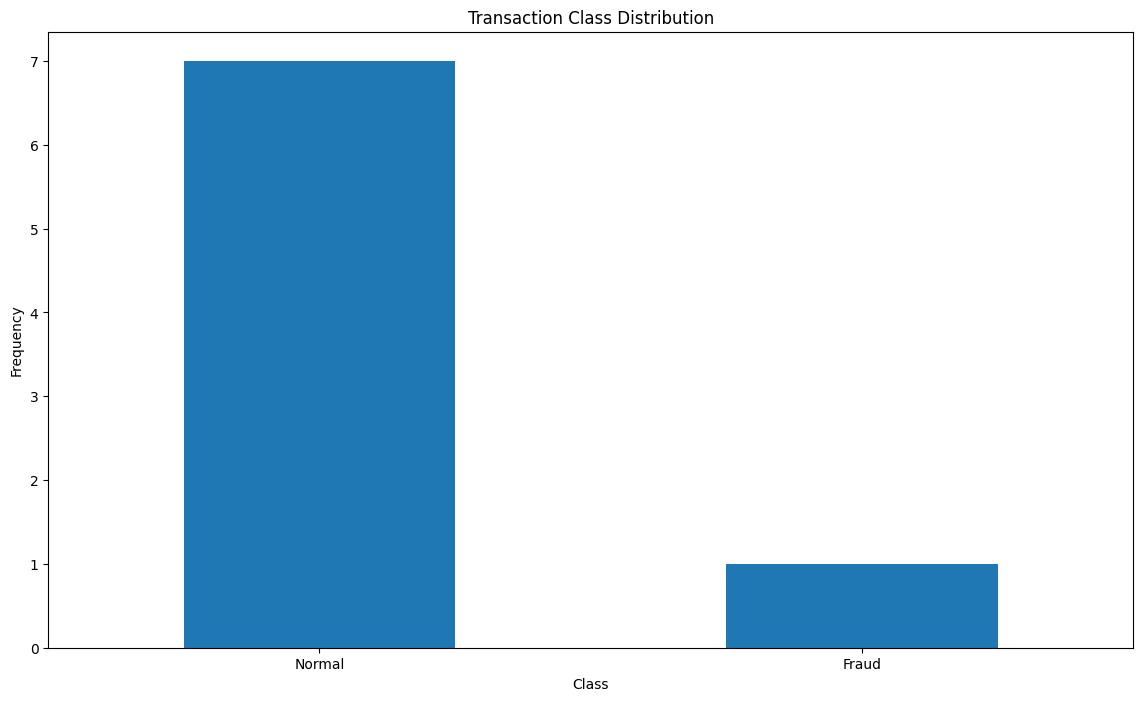

In [12]:
count_classes = data['Class'].value_counts(sort=True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

In [13]:
fraud = data[data['Class']==1]
normal = data[data['Class']==0]
print(fraud.shape,normal.shape)

(7, 15) (1, 15)


In [14]:
fraud.Amount.describe()

,Amount
count,7.000000
mean,12.860029
std,0.249761
min,12.300800
25%,12.924350
50%,12.925000
75%,12.967450
max,13.010800


In [15]:
normal.Amount.describe()

,Amount
count,1.0000
mean,12.3051
std,NaN
min,12.3051
25%,12.3051
50%,12.3051
75%,12.3051
max,12.3051


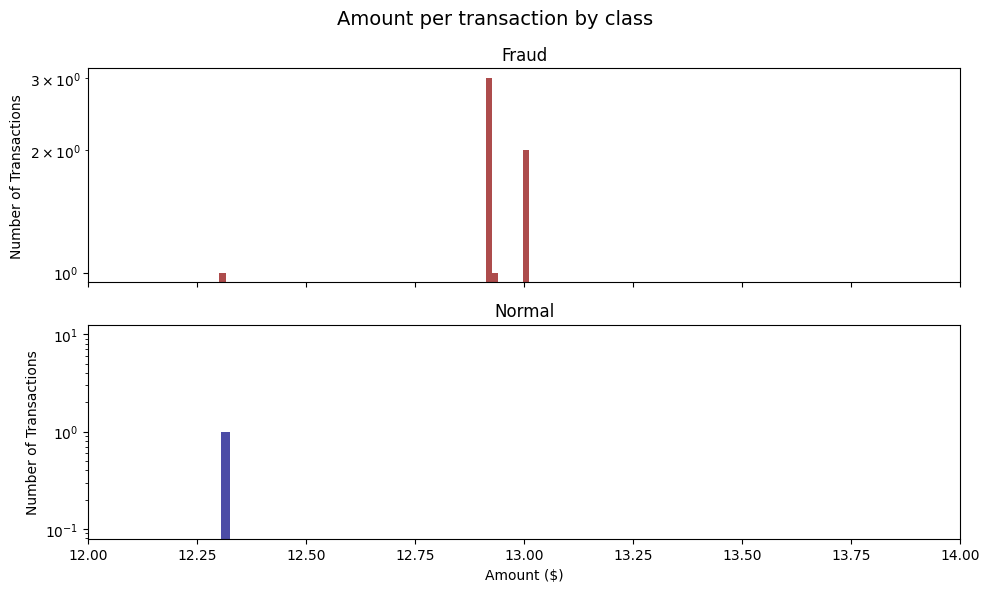

In [45]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
f.suptitle('Amount per transaction by class', fontsize=14)
bins = 50
ax1.hist(fraud.Amount, bins=bins, color='darkred', alpha=0.7)
ax1.set_title('Fraud')
ax1.set_ylabel('Number of Transactions')
ax1.set_yscale('log')
ax2.hist(normal.Amount, bins=bins, color='navy', alpha=0.7)
ax2.set_title('Normal')
ax2.set_ylabel('Number of Transactions')
ax2.set_yscale('log')
plt.xlabel('Amount ($)')
plt.xlim((12, 14))
plt.tight_layout()
plt.show()

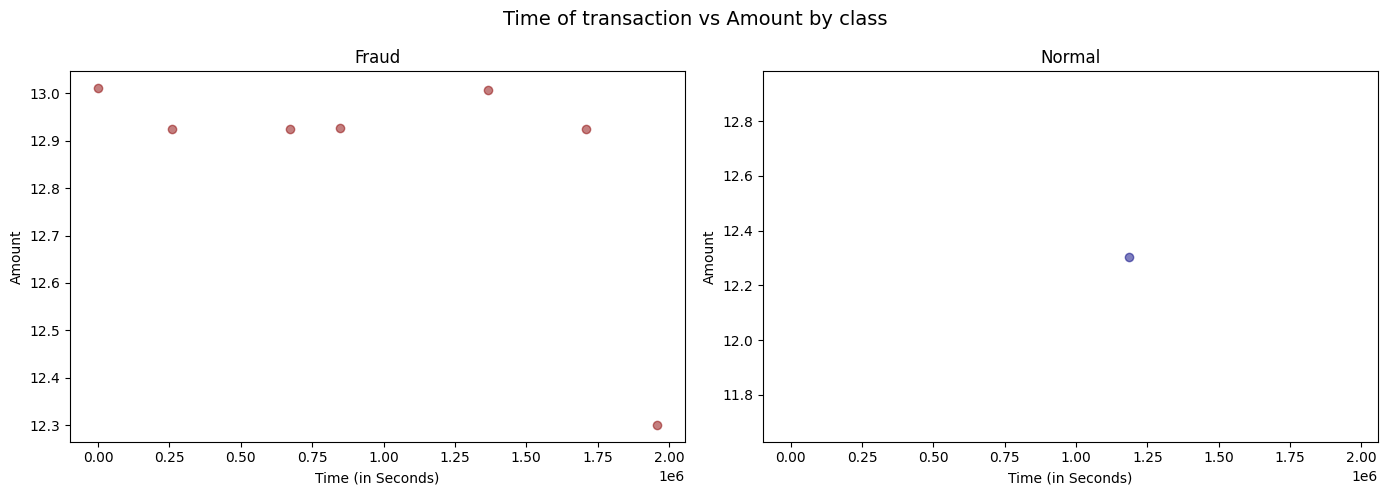

In [17]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
f.suptitle('Time of transaction vs Amount by class', fontsize=14)
ax1.scatter(fraud.Time, fraud.Amount, color='darkred', alpha=0.5)
ax1.set_title('Fraud')
ax1.set_xlabel('Time (in Seconds)')
ax1.set_ylabel('Amount')
ax2.scatter(normal.Time, normal.Amount, color='navy', alpha=0.5)
ax2.set_title('Normal')
ax2.set_xlabel('Time (in Seconds)')
ax2.set_ylabel('Amount')
plt.tight_layout()
plt.show()

In [36]:
# For this very small and imbalanced dataset, using the full data instead of sampling
# to ensure both 'Normal' and 'Fraud' cases are present for anomaly detection.
data1 = data.copy()
data1.shape

(8, 15)

In [19]:
data.shape

(8, 15)

In [37]:
Fraud = data1[data1['Class']==1]
Valid = data1[data1['Class']==0]

# Calculate outlier fraction as proportion of fraud cases in the total dataset
outlier_proportion_raw = len(Fraud) / float(len(data1))

# Cap outlier_fraction at 0.5 to satisfy model requirements for 'contamination'
outlier_fraction = min(outlier_proportion_raw, 0.5)

print(f"Raw Outlier Proportion: {outlier_proportion_raw}")
print(f"Capped Outlier Fraction (for models): {outlier_fraction}")
print("Fraud Cases : {}".format(len(Fraud)))
print("Valid Cases : {}".format(len(Valid)))

Raw Outlier Proportion: 0.875
Capped Outlier Fraction (for models): 0.5
Fraud Cases : 7
Valid Cases : 1


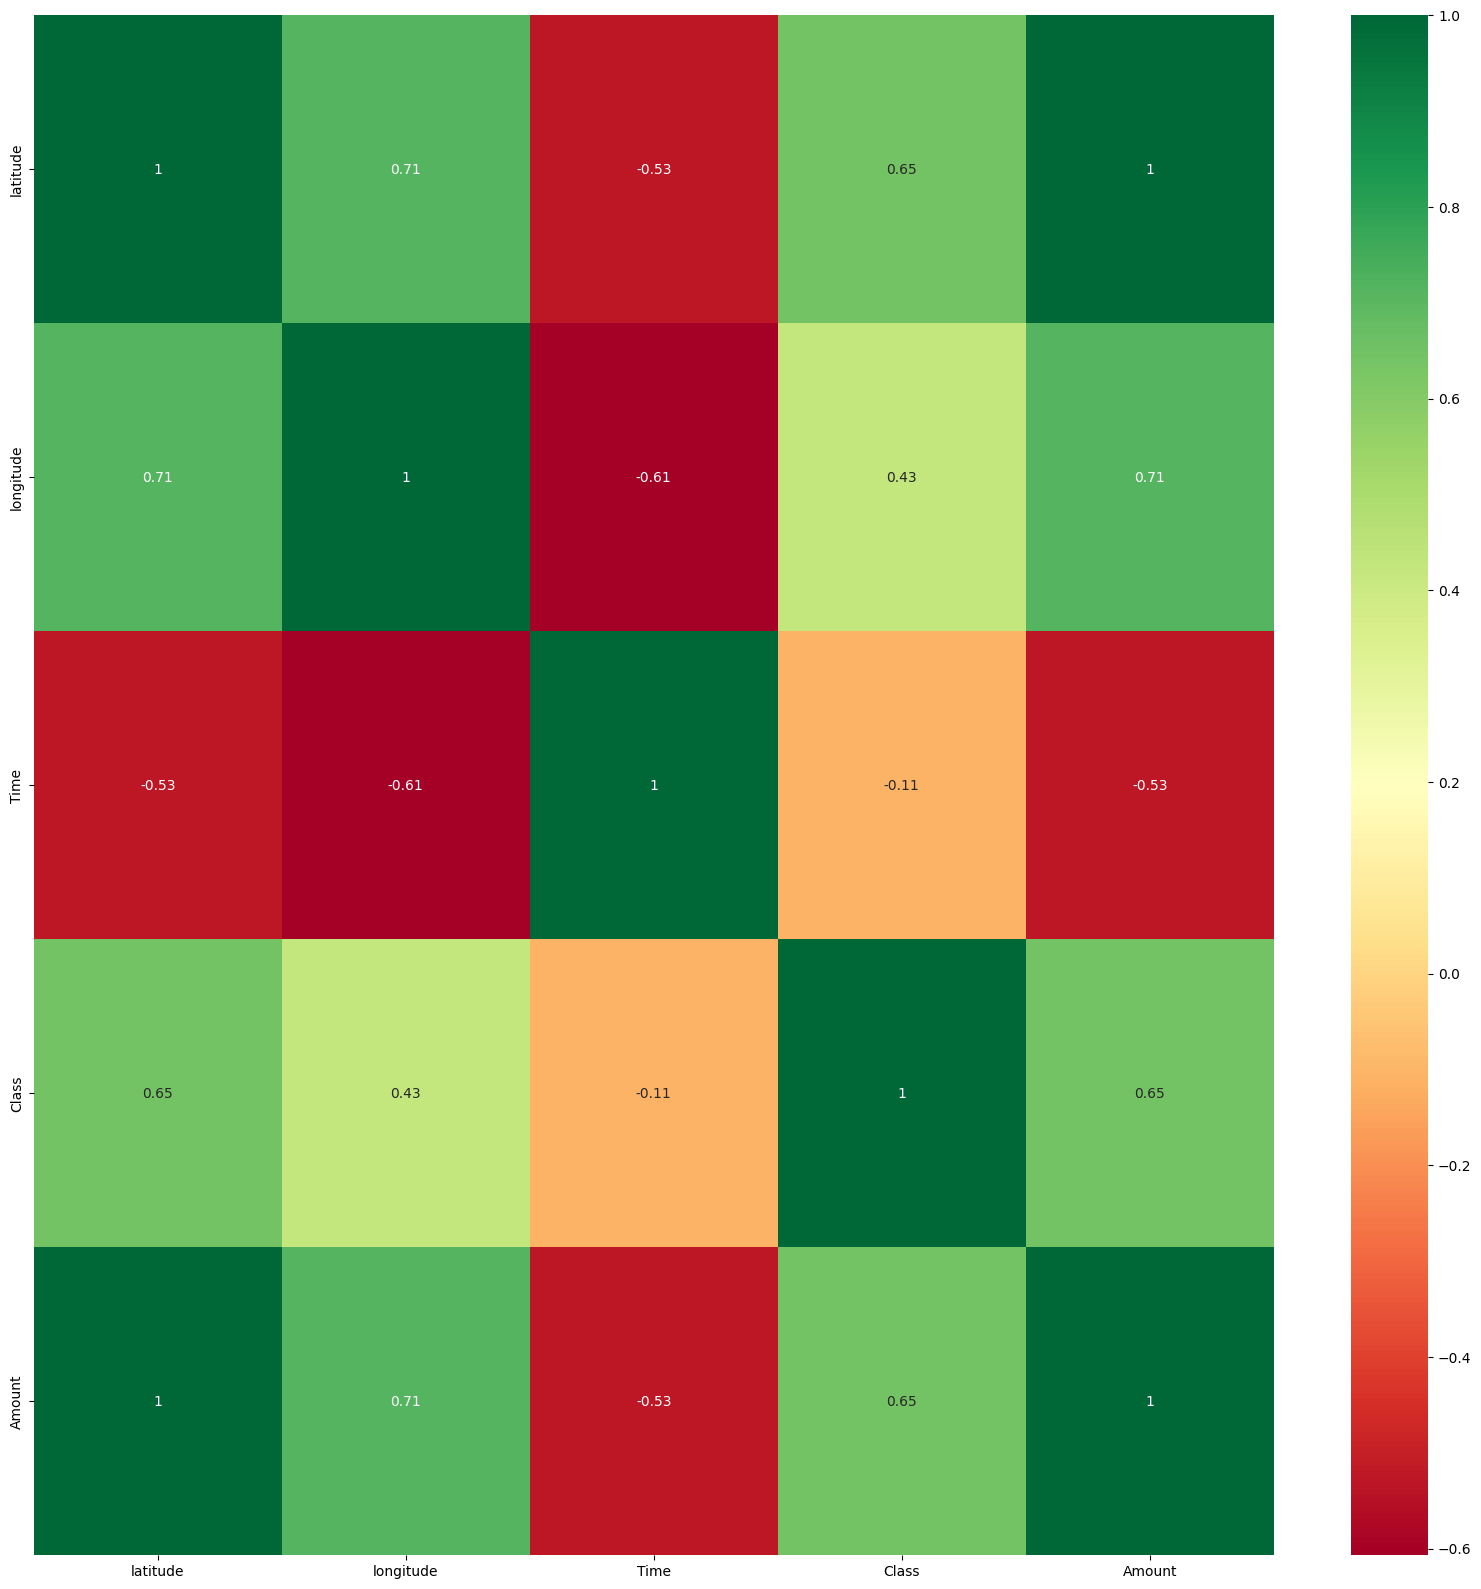

In [38]:
import seaborn as sns
corrmat = data1.corr(numeric_only=True)
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
g=sns.heatmap(data1[top_corr_features].corr(numeric_only=True),annot=True,cmap="RdYlGn")

In [39]:
columns = data1.columns.tolist()
# Filter out 'Class' and non-numeric columns (like 'reported_at' if not converted, or object Dtype columns)
columns = [c for c in columns if c not in ["Class"] and pd.api.types.is_numeric_dtype(data1[c])]

In [40]:
target = "Class"
state = np.random.RandomState(42)
X = data1[columns]
Y = data1[target]
X_outliers = state.uniform(low=0, high=1,size=(X.shape[0],X.shape[1]))
print(X.shape)
print(Y.shape)

(8, 4)
(8,)


In [41]:
classifiers = {"Isolation Forest":IsolationForest(n_estimators=100,max_samples=len(X),
contamination=outlier_fraction,random_state=state, verbose=0),
"Local Outlier Factor":LocalOutlierFactor(n_neighbors=20, algorithm='auto',
leaf_size=30,metric='minkowski',p=2, metric_params=None, contamination=outlier_fraction)
}

In [42]:
type(classifiers)

dict

In [43]:
n_outliers = len(Fraud)
for i, (clf_name, clf) in enumerate(classifiers.items()):
    # Fit the data and tag outliers
    if clf_name == "Local Outlier Factor":
        y_pred = clf.fit_predict(X)
        scores_prediction = clf.negative_outlier_factor_
    else:
        clf.fit(X)
        scores_prediction = clf.decision_function(X)
        y_pred = clf.predict(X)

    # Reshape the prediction values to 0 for Normal and 1 for Fraud
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1

    n_errors = (y_pred != Y).sum()
    print(f"{clf_name} - Outlier Errors: {n_errors}")
    print("Accuracy Score :",accuracy_score(Y,y_pred))
    print("Classification Report :")
    print(classification_report(Y,y_pred))

Isolation Forest - Outlier Errors: 5
Accuracy Score : 0.375
Classification Report :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      0.43      0.55         7

    accuracy                           0.38         8
   macro avg       0.38      0.21      0.27         8
weighted avg       0.66      0.38      0.48         8

Local Outlier Factor - Outlier Errors: 5
Accuracy Score : 0.375
Classification Report :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      0.43      0.55         7

    accuracy                           0.38         8
   macro avg       0.38      0.21      0.27         8
weighted avg       0.66      0.38      0.48         8



/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_lof.py:282: UserWarning: n_neighbors (20) is greater than the total number of samples (8). n_neighbors will be set to (n_samples - 1) for estimation.
  warnings.warn(
